# **Machine Learning II Project**

### Customer Segmantation: A Key to Unlocking Business Growth and Success

## Project Members - **Group 4**

- **Bernardo da Costa Marques Amaral Caldas**, 20231675
- **David Bizarro dos Santos**, 20231594
- **Inês de Sousa Ribeiros Vicente**, 20231599

-----

# **Data Analysis**

In [8]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import folium
import webbrowser

In [9]:
dataset = pd.read_csv('data/customer_info.csv')
display(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34060 entries, 0 to 34059
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Unnamed: 0                               34060 non-null  int64  
 1   customer_id                              34060 non-null  int64  
 2   customer_name                            34060 non-null  object 
 3   customer_gender                          34060 non-null  object 
 4   customer_birthdate                       33719 non-null  object 
 5   kids_home                                33311 non-null  float64
 6   teens_home                               33277 non-null  float64
 7   number_complaints                        33038 non-null  float64
 8   distinct_stores_visited                  33379 non-null  float64
 9   lifetime_spend_groceries                 34060 non-null  float64
 10  lifetime_spend_electronics               34060

None

In [10]:
dataset = dataset.iloc[:,5:] # to work just with the numerical data
display(dataset.info())
display(dataset.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34060 entries, 0 to 34059
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   kids_home                                33311 non-null  float64
 1   teens_home                               33277 non-null  float64
 2   number_complaints                        33038 non-null  float64
 3   distinct_stores_visited                  33379 non-null  float64
 4   lifetime_spend_groceries                 34060 non-null  float64
 5   lifetime_spend_electronics               34060 non-null  float64
 6   typical_hour                             32698 non-null  float64
 7   lifetime_spend_vegetables                33038 non-null  float64
 8   lifetime_spend_nonalcohol_drinks         34060 non-null  float64
 9   lifetime_spend_alcohol_drinks            33379 non-null  float64
 10  lifetime_spend_meat                      34060

None

,count,mean,std,min,25%,50%,75%,max
kids_home,33311.0,1.170244,1.307319,0.000000,0.000000,1.000000,1.000000,10.000000
teens_home,33277.0,0.936292,0.759579,0.000000,0.000000,1.000000,1.000000,4.000000
number_complaints,33038.0,0.832042,0.771205,0.000000,0.000000,1.000000,1.000000,4.000000
distinct_stores_visited,33379.0,2.914078,1.549081,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,34060.0,22818.404698,20098.763199,0.000000,9346.000000,15877.500000,30428.250000,158544.000000
lifetime_spend_electronics,34060.0,3816.022343,3858.352640,0.000000,860.000000,2958.000000,5309.000000,37523.000000
typical_hour,32698.0,13.200746,4.681384,6.000000,9.000000,13.000000,16.000000,24.000000
lifetime_spend_vegetables,33038.0,738.642079,679.599323,0.000000,222.000000,451.000000,1089.750000,5380.000000
lifetime_spend_nonalcohol_drinks,34060.0,478.382854,282.132536,0.000000,231.000000,453.000000,661.000000,1702.000000
lifetime_spend_alcohol_drinks,33379.0,838.482998,596.518224,1.000000,347.000000,705.000000,1299.000000,4907.000000


To begin the exploratory data analysis, we assessed the number of unique values in each variable of the dataset. This step allowed us to classify variables into two groups:

- Variables with **few unique values**, which will be analyzed using **count plots**, as this visualization is appropriate for categorical or discrete variables with limited categories.

- Variables with **many unique values**, which will be analyzed with **histograms**, as these charts provide better insights into the distribution of continuous or high-cardinality variables.

In [12]:
for i in dataset.columns:
    print(i, dataset[i].nunique())

kids_home 11
teens_home 5
number_complaints 5
distinct_stores_visited 10
lifetime_spend_groceries 24173
lifetime_spend_electronics 10245
typical_hour 19
lifetime_spend_vegetables 2591
lifetime_spend_nonalcohol_drinks 1399
lifetime_spend_alcohol_drinks 2556
lifetime_spend_meat 2361
lifetime_spend_fish 2789
lifetime_spend_hygiene 2305
lifetime_spend_videogames 1741
lifetime_spend_petfood 858
lifetime_total_distinct_products 620
percentage_of_products_bought_promotion 34060
year_first_transaction 32
loyalty_card_number 20650
latitude 34060
longitude 34060


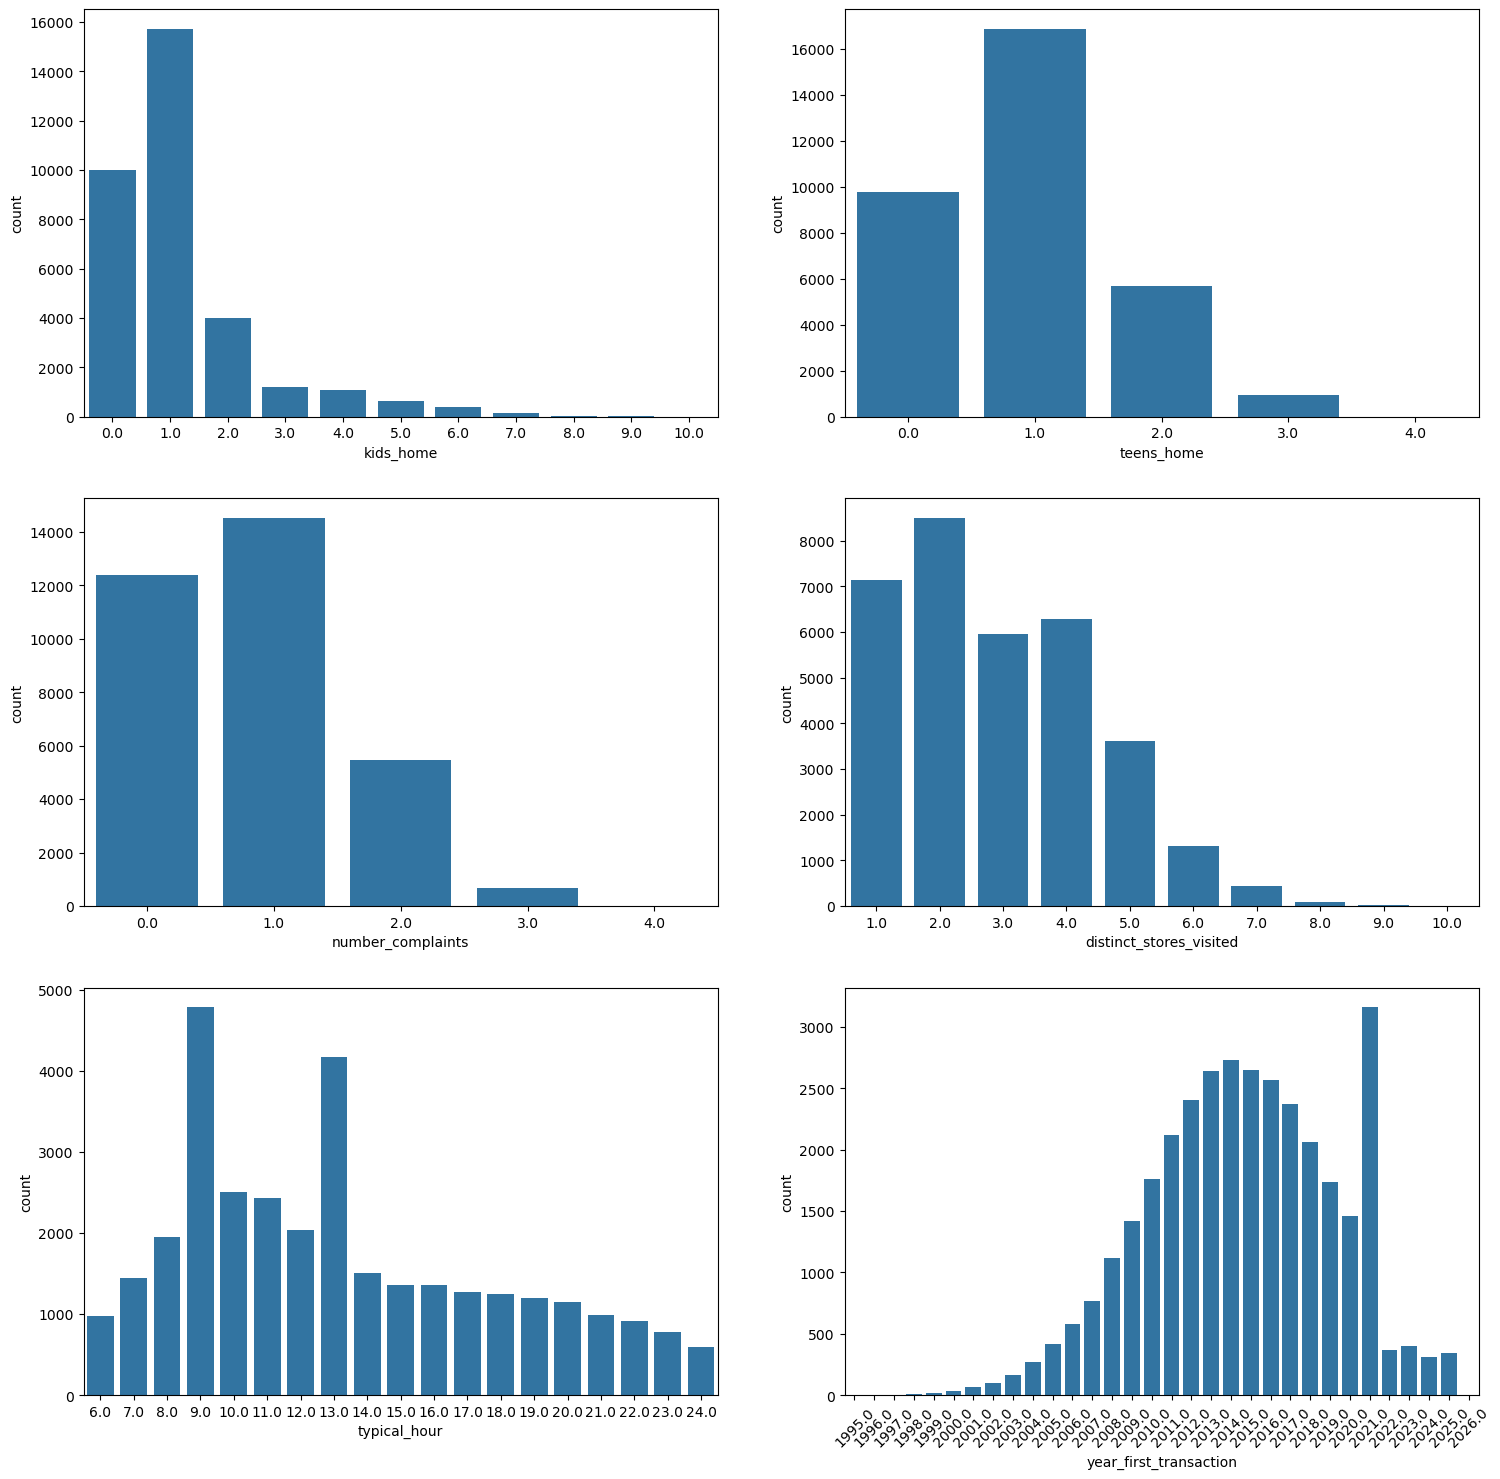

In [13]:
fig, ax = plt.subplots(3, 2, figsize=(18, 18))
sns.countplot(data=dataset, x='kids_home', ax=ax[0][0])
sns.countplot(data=dataset, x='teens_home', ax=ax[0][1])
sns.countplot(data=dataset, x='number_complaints', ax=ax[1][0])
sns.countplot(data=dataset, x='distinct_stores_visited', ax=ax[1][1])
sns.countplot(data=dataset, x='typical_hour', ax=ax[2][0])
sns.countplot(data=dataset, x='year_first_transaction', ax=ax[2][1]).tick_params(axis='x', rotation=45)

<Axes: xlabel='percentage_of_products_bought_promotion', ylabel='Count'>

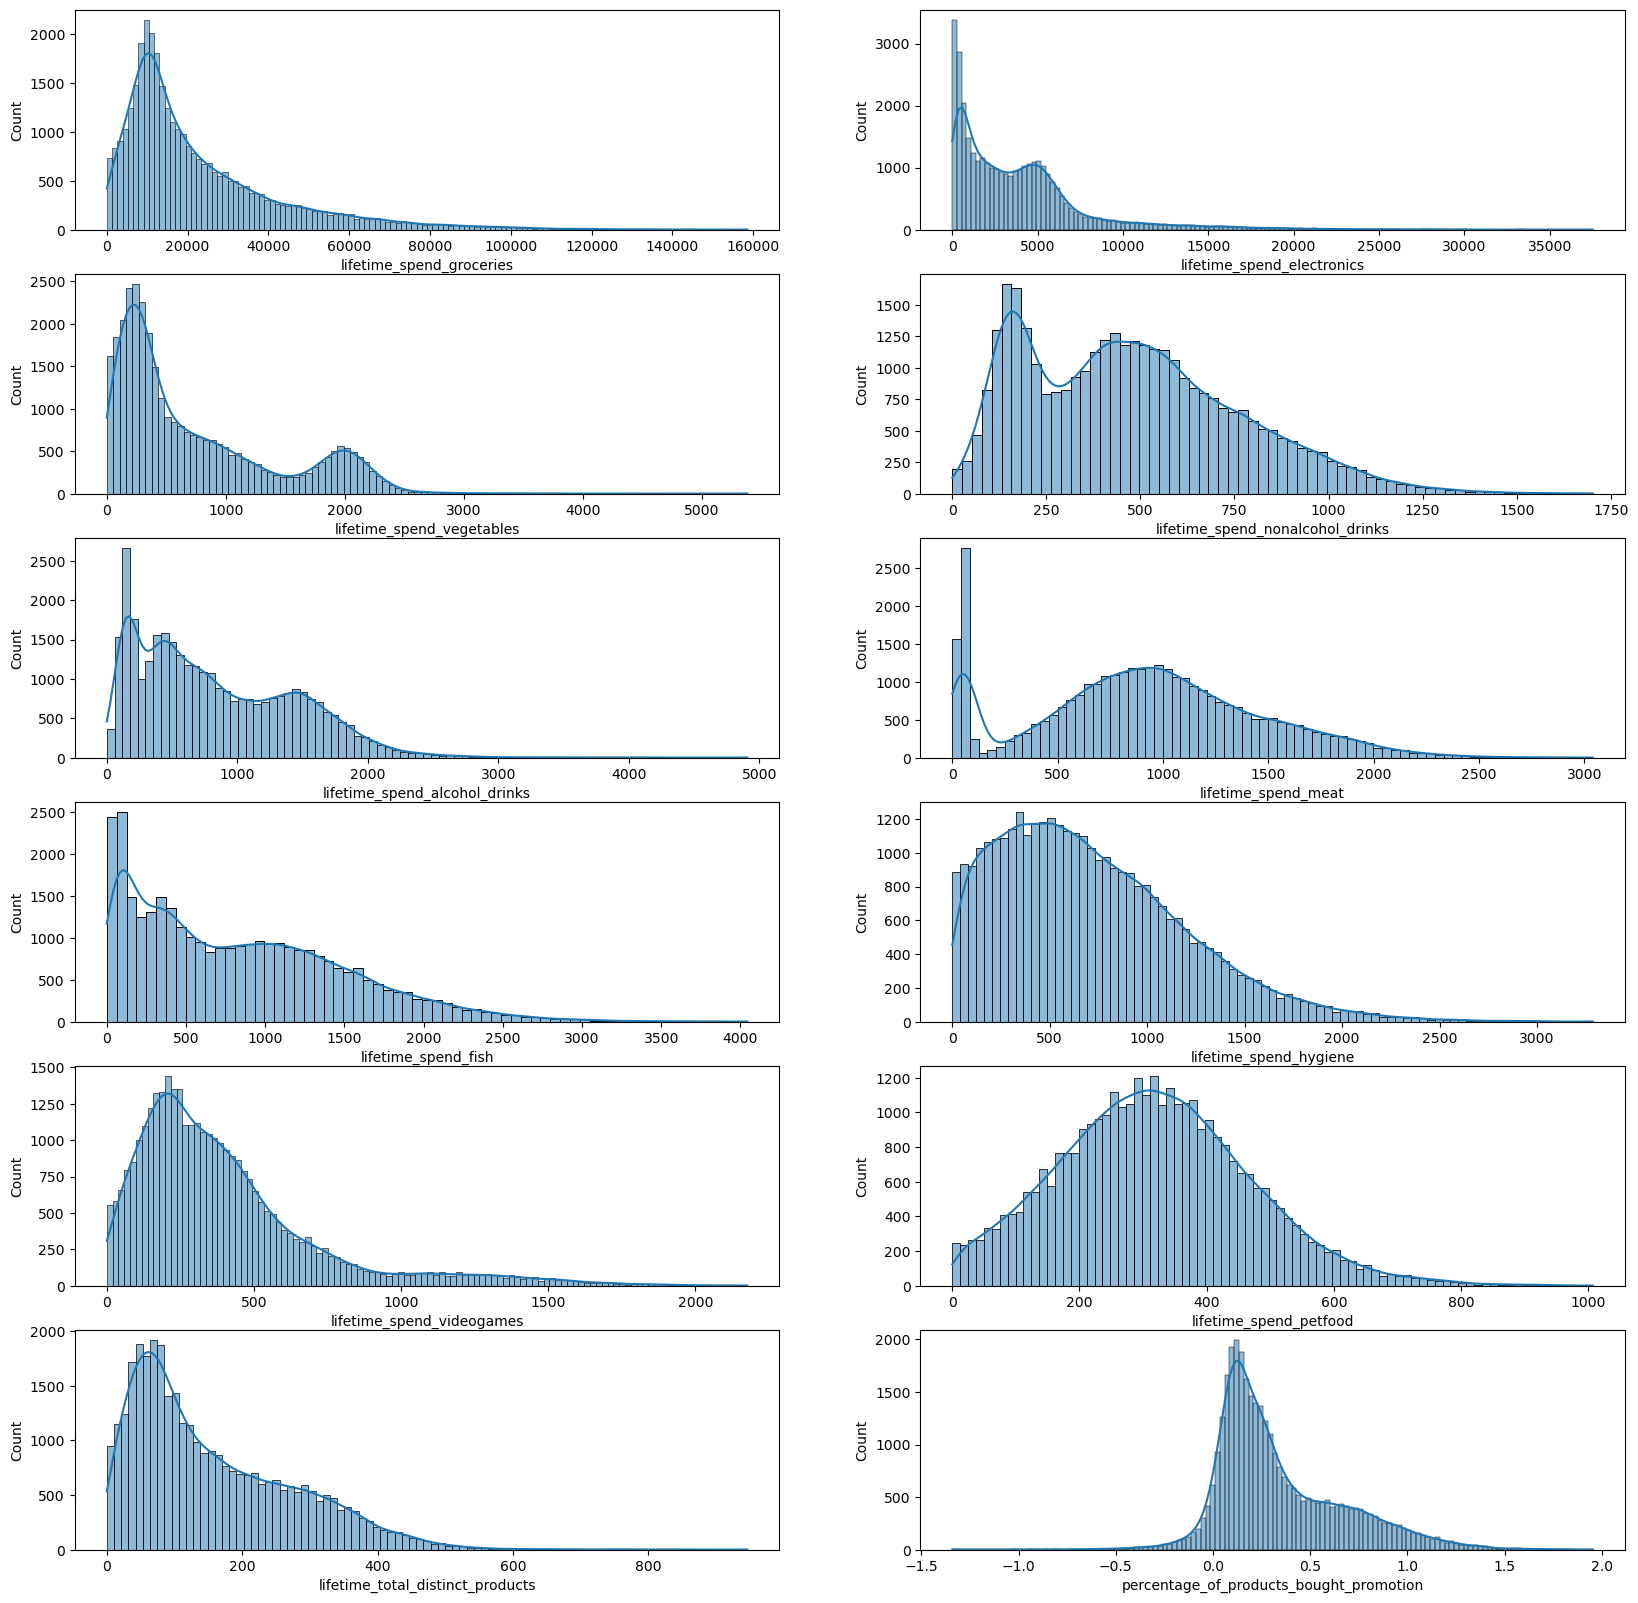

In [14]:
fig, ax = plt.subplots(6, 2, figsize=(20, 20))
sns.histplot(dataset['lifetime_spend_groceries'], ax=ax[0][0], kde=True)
sns.histplot(dataset['lifetime_spend_electronics'], ax=ax[0][1], kde=True)
sns.histplot(dataset['lifetime_spend_vegetables'], ax=ax[1][0], kde=True)
sns.histplot(dataset['lifetime_spend_nonalcohol_drinks'], ax=ax[1][1], kde=True)
sns.histplot(dataset['lifetime_spend_alcohol_drinks'], ax=ax[2][0], kde=True)
sns.histplot(dataset['lifetime_spend_meat'], ax=ax[2][1], kde=True)
sns.histplot(dataset['lifetime_spend_fish'], ax=ax[3][0], kde=True)
sns.histplot(dataset['lifetime_spend_hygiene'], ax=ax[3][1], kde=True)
sns.histplot(dataset['lifetime_spend_videogames'], ax=ax[4][0], kde=True)
sns.histplot(dataset['lifetime_spend_petfood'], ax=ax[4][1], kde=True)
sns.histplot(dataset['lifetime_total_distinct_products'], ax=ax[5][0], kde=True)
sns.histplot(dataset['percentage_of_products_bought_promotion'], ax=ax[5][1], kde=True)

## Analysis

- **Household Composition:** The number of kids and teens at home show a skewed distribution, with most customers having **fewer children or teenagers**.

- **Number of Complaints:** The majority of customers report zero or very few complaints, indicating generally **high satisfaction levels**.

- **Distinct Stores Visited:** Customers typically visit between 1 and 4 distinct stores, suggesting **moderate store loyalty**.

- **Typical Hour:** The time of purchase clusters mainly around late mornings to early afternoons, with **peaks at 9 and 13**.

- **Year of First Transaction:** Most customers have been active since the **mid-2000s**, with a significant number at **2020**.

- **Spending Variables:** Lifetime spend on groceries, electronics, vegetables, non-alcoholic drinks, alcohol, meat, fish, video games, pet food, and total distinct products show right-skewed distributions. This indicates a small proportion of high spenders and a larger proportion of **moderate to low spenders** across all categories.

- **Percentage of Products Bought on Promotion:** This is mostly concentrated **near zero**, suggesting that a majority of customers purchase few promoted products, with a long tail representing more promotion-savvy buyers. Negative values do not seem to make much sense in this context.

In [ ]:
# Create a map centered around the average location
map_center = [dataset["latitude"].mean(), dataset["longitude"].mean()]
m = folium.Map(location=map_center, zoom_start=13)

# Add circle markers for better visibility
for _, row in dataset.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='blue',
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

# Save and open the map in browser
m.save("map.html")
webbrowser.open("map.html")

True

A **map** was generated to visualize the **locations of all customers** in the dataset, and it was concluded that all were located in the **Lisbon** area.